# 306: GHG/Residual Methodology Comparison Check

**Question:** why did the median `Residual` contribution (`ANTHROPOGENIC - GHG`) shrink from ~+0.03\u00b0C
(old pipeline) to ~0\u00b0C (current pipeline) between net-zero CO2 and 2100? Two candidate explanations were
raised:

1. **Basket redefinition**: the old pipeline's native `GHG` mode bundles Montreal Protocol halogens
   together with the Kyoto gases; the current pipeline's `GHG` (via QEXTRA) is Kyoto-gases-only
   (`CO2+CH4+N2O+F-Gases`), so Montreal-halogen-driven warming that used to sit inside `NonCO2_GHG` now
   falls into `Residual` instead.
2. **Methodology fix**: the current pipeline computes `NonCO2_GHG` via **subtraction** of two QEXTRA passes
   fed by ERF harvested from the real scenario, rather than via **native-mode differencing**
   (`GHG`-native minus `CO2`-native, two independently-forced runs) - the native approach evaluates
   MAGICC's state-dependent temperature-response nonlinearity at a different background-warming level than
   the real scenario (see `notes/magicc-carbon-cycle-feedback-mechanics.md`).

A matched-scenario comparison of the *saved output* from both pipelines (641 scenarios present in both the
v1.0 and v1.1 databases) found the two candidate effects roughly split the observed shift 50/50 - but that
comparison mixes the MAGICC-methodology change with the SCI v1.0\u2192v1.1 database re-harmonisation/infilling
change, since both happened between the two saved datasets.

**This notebook isolates the MAGICC-methodology question alone**, holding the input emissions fixed at the
**current (v1.1) database only** (per instruction - no v1.0 emissions are used here). For 3 real scenarios
(chosen from the 641 matched scenarios, to be informative about the observed shift - see below), it runs a
**controlled 2x2**: {native-mode differencing vs. QEXTRA subtraction} x {Kyoto-only vs. Kyoto+Montreal
basket}, using the *same* v1.1 emissions throughout, so any difference between the four combinations is
attributable purely to MAGICC-side methodology, not the database.

## Scenarios used (v1.1 emissions only)

Chosen from the 641 model/scenario pairs present in both the old (`output_gaurav/`) and current
(`output_revision/`) saved datasets, to span the range of the observed old-vs-new Residual shift:

| Model | Scenario | year_netzero_co2 | Saved-output Residual shift (new - old) |
|---|---|---|---|
| REMIND 3.5 | Rescuing-1.5\u00b0C-Highest-Possible-Ambition | 2045 | -0.259\u00b0C (largest negative) |
| IMAGE 3.0 | ENGAGE-INDCi2030-1000f | 2069 | -0.037\u00b0C (near-median) |
| TIAM-ECN 1.1 | ENGAGE-INDCi2030-900f | 2069 | +0.058\u00b0C (largest positive) |

## MAGICC passes run per scenario

1. **Harvest** (`rf_total_runmodus="ANTHROPOGENIC"`): GSAT + component ERFs (CO2, CH4, N2O, F-Gases,
   Montreal Protocol Halogen Gases). This run's own GSAT *is* the `ANTHROPOGENIC` total.
2. **QEXTRA, CO2-only**: forcing = harvested CO2 ERF alone.
3. **QEXTRA, Kyoto-only** (current production `GHG` flag): forcing = harvested CO2+CH4+N2O+F-Gases.
4. **QEXTRA, Kyoto+Montreal** (new variant for this check): forcing = harvested
   CO2+CH4+N2O+F-Gases+Montreal Protocol Halogen Gases.
5. **Native `ALL`** (old pipeline's total-forcing flag - includes natural/solar/volcanic, unlike
   `ANTHROPOGENIC`).
6. **Native `GHG`** (old pipeline's GHG flag - MAGICC's built-in bundling of Kyoto gases + Montreal
   halogens).
7. **Native `CO2`** (old pipeline's CO2 flag).

That's 7 MAGICC passes x 3 scenarios. Raw (uncalibrated) GSAT is used throughout - appropriate here since
we only ever compare *differences* between passes on the *same* ensemble, and calibration is a scalar
shift that would cancel out of any such difference anyway.

## Derived comparison quantities

- `Residual_new_kyoto_only` = ANTHROPOGENIC - QEXTRA(Kyoto-only) — current production methodology
- `Residual_new_kyoto_mhalo` = ANTHROPOGENIC - QEXTRA(Kyoto+Montreal) — subtraction methodology, old-style basket
- `Residual_old` = NATIVE(ALL) - NATIVE(GHG) — old methodology, reproduced on v1.1 emissions
- `NonCO2_GHG_new_kyoto_only` = QEXTRA(Kyoto-only) - QEXTRA(CO2)
- `NonCO2_GHG_new_kyoto_mhalo` = QEXTRA(Kyoto+Montreal) - QEXTRA(CO2)
- `NonCO2_GHG_old` = NATIVE(GHG) - NATIVE(CO2)

Comparing `Residual_new_kyoto_mhalo` vs. `Residual_old` (same basket, different methodology) isolates the
*methodology* effect; comparing `Residual_new_kyoto_only` vs. `Residual_new_kyoto_mhalo` (same methodology,
different basket) isolates the *basket* effect.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger("pint.util").setLevel(logging.ERROR)

import os
import platform
from pathlib import Path

from gcages.cmip7_scenariomip.scm_running import CMIP7ScenarioMIPSCMRunner

import dotenv
import numpy as np
import pandas_indexing as pix
from pandas_openscm.io import load_timeseries_csv
import pandas as pd
import matplotlib.pyplot as plt

from utils import sanitize_label, write_magicc_extra_rf_file

dotenv.load_dotenv()

OUTPUT_FOLDER = Path(os.environ["OUTPUT_FOLDER"])
DIAG_FOLDER = OUTPUT_FOLDER / "306_ghg_methodology_check"
DIAG_FOLDER.mkdir(parents=True, exist_ok=True)
PLOT_FOLDER = OUTPUT_FOLDER / "plots"
PLOT_FOLDER.mkdir(parents=True, exist_ok=True)

In [2]:
# Configuration
ENSEMBLE_MEMBERS = 25  # modest sample for a diagnostic check, not a full production run
N_PROCESSES = 4

FILE = OUTPUT_FOLDER / "100_harmonised_infilled_data.csv"

SCENARIOS = [
    {"model": "REMIND 3.5", "scenario": "Rescuing-1.5\u00b0C-Highest-Possible-Ambition", "year_netzero_co2": 2045},
    {"model": "IMAGE 3.0", "scenario": "ENGAGE-INDCi2030-1000f", "year_netzero_co2": 2069},
    {"model": "TIAM-ECN 1.1", "scenario": "ENGAGE-INDCi2030-900f", "year_netzero_co2": 2069},
]

BASE_DIR = Path("../../gcages/tests/regression/cmip7-scenariomip/cmip7-scenariomip-workflow-inputs")
CMIP7_SCENARIOMIP_GLOBAL_HISTORICAL_EMISSIONS = BASE_DIR / "history_cmip7_scenariomip.csv"

MAGICC_EXE_PATH = BASE_DIR / "magicc-v7.6.0a3" / "bin"
MAGICC_CMIP7_SCENARIOMIP_PROBABILISTIC_CONFIG_FILE = (
    BASE_DIR / "magicc-v7.6.0a3" / "configs" / "magicc-ar7-fast-track-drawnset-v0-3-0.json"
)

if platform.system() == "Darwin":
    if platform.processor() == "arm":
        MAGICC_EXE = MAGICC_EXE_PATH / "magicc-darwin-arm64"
        os.environ["DYLD_LIBRARY_PATH"] = "/opt/homebrew/Cellar/gcc/15.2.0_1/lib/gcc/current"
elif platform.system() == "Linux":
    MAGICC_EXE = MAGICC_EXE_PATH / "magicc"
elif platform.system() == "Windows":
    MAGICC_EXE = MAGICC_EXE_PATH / "magicc.exe"

In [3]:
start = load_timeseries_csv(
    FILE,
    index_columns=["model", "scenario", "region", "variable", "unit"],
    out_columns_type=int,
    out_columns_name="year",
)

## ERF Baskets and MAGICC Runner Helpers

In [4]:
CO2_EFFRF_COMPONENTS = ("Effective Radiative Forcing|CO2",)

KYOTO_EFFRF_COMPONENTS = (
    "Effective Radiative Forcing|CO2",
    "Effective Radiative Forcing|CH4",
    "Effective Radiative Forcing|N2O",
    "Effective Radiative Forcing|F-Gases",
)

MHALO_EFFRF_COMPONENTS = ("Effective Radiative Forcing|Montreal Protocol Halogen Gases",)

KYOTO_MHALO_EFFRF_COMPONENTS = KYOTO_EFFRF_COMPONENTS + MHALO_EFFRF_COMPONENTS

# All component ERFs we need harvested from the single ANTHROPOGENIC pass, to build
# every QEXTRA basket below (the harvest pass must request the union of everything).
HARVEST_EFFRF_COMPONENTS = KYOTO_MHALO_EFFRF_COMPONENTS

# QEXTRA baskets: {flag_label: component ERFs summed to build that basket's forcing}
QEXTRA_BASKETS = {
    "QEXTRA_CO2": CO2_EFFRF_COMPONENTS,
    "QEXTRA_GHG_kyoto_only": KYOTO_EFFRF_COMPONENTS,
    "QEXTRA_GHG_kyoto_plus_mhalo": KYOTO_MHALO_EFFRF_COMPONENTS,
}

# Old-pipeline native passes: {flag_label: MAGICC's native rf_total_runmodus value}
NATIVE_RUNMODI = {
    "NATIVE_ALL": "ALL",
    "NATIVE_GHG": "GHG",
    "NATIVE_CO2": "CO2",
}

In [5]:
def build_scm_runner(output_variables):
    """Build a scm runner truncated to ENSEMBLE_MEMBERS. Each call reloads the same
    probabilistic config JSON, so member order/count (and therefore run_id alignment
    across separately-built runners) is deterministic."""
    runner = CMIP7ScenarioMIPSCMRunner.from_cmip7_scenariomip_config(
        n_processes=N_PROCESSES,
        magicc_exe_path=MAGICC_EXE,
        magicc_prob_distribution_path=MAGICC_CMIP7_SCENARIOMIP_PROBABILISTIC_CONFIG_FILE,
        historical_emissions_path=CMIP7_SCENARIOMIP_GLOBAL_HISTORICAL_EMISSIONS,
        output_variables=output_variables,
        batch_size_scenarios=15,
    )
    runner.climate_models_cfgs["MAGICC7"] = runner.climate_models_cfgs["MAGICC7"][:ENSEMBLE_MEMBERS]
    return runner


def sum_effrf_components(erf_results, components):
    """Sum a basket of component ERF series per ensemble member (run_id) and year."""
    summed = (
        erf_results
        .loc[pix.isin(variable=list(components))]
        .groupby(level="run_id")
        .sum(numeric_only=True)
    )
    year_columns = [c for c in summed.columns if isinstance(c, int)]
    return summed[year_columns]


def to_wide_gsat(gsat_result):
    """Convert a pandas-indexing-style GSAT result (MultiIndex incl. run_id, year columns)
    into a plain run_id-indexed, integer-year-columns DataFrame."""
    df = gsat_result.reset_index()
    year_cols = [c for c in df.columns if isinstance(c, int)]
    return df.set_index("run_id")[year_cols].sort_index()


def run_native_pass(scenario_to_run, runmodus):
    """Run a single native-rf_total_runmodus MAGICC pass, returning wide GSAT."""
    runner = build_scm_runner(output_variables=("Surface Air Temperature Change",))
    runner.climate_models_cfgs["MAGICC7"] = [
        {**c, "rf_total_runmodus": runmodus}
        for c in runner.climate_models_cfgs["MAGICC7"]
    ]
    result = runner(scenario_to_run)
    return to_wide_gsat(result)


def run_qextra_pass(erf_results, components, basket_label, qextra_root):
    """Sum `components` from the harvested erf_results, write per-member QEXTRA forcing
    files, and run a QEXTRA MAGICC pass driven by exactly that basket's forcing."""
    qextra_effrf = sum_effrf_components(erf_results, components)

    qextra_forcing_dir = qextra_root / basket_label
    for run_id, row in qextra_effrf.iterrows():
        write_magicc_extra_rf_file(
            qextra_forcing_dir / f"member_{run_id}.IN",
            years=list(row.index),
            values=list(row.values),
            description=f"{basket_label} ERF, ensemble member {run_id}",
        )

    qextra_runner = build_scm_runner(output_variables=("Surface Air Temperature Change",))
    qextra_cfgs_by_id = {c["run_id"]: c for c in qextra_runner.climate_models_cfgs["MAGICC7"]}
    survived_run_ids = [rid for rid in qextra_effrf.index if rid in qextra_cfgs_by_id]

    qextra_runner.climate_models_cfgs["MAGICC7"] = [
        {
            **qextra_cfgs_by_id[run_id],
            "file_extra_rf": str(qextra_forcing_dir / f"member_{run_id}.IN"),
            "rf_extra_read": 1,
            "rf_total_runmodus": "QEXTRA",
        }
        for run_id in survived_run_ids
    ]
    result = qextra_runner(scenario_to_run)
    return to_wide_gsat(result)

## Run All Passes for All 3 Scenarios

In [6]:
all_results = {}  # (model, scenario, flag) -> wide GSAT DataFrame (run_id x year)

for spec in SCENARIOS:
    model, scenario = spec["model"], spec["scenario"]
    print(f"\n{'='*70}\n{model} | {scenario}\n{'='*70}")

    sanitized_model = sanitize_label(model)
    sanitized_scenario = sanitize_label(scenario)
    scenario_root = DIAG_FOLDER / f"{sanitized_model}_{sanitized_scenario}"
    scenario_root.mkdir(parents=True, exist_ok=True)

    scenario_to_run = start.loc[pd.IndexSlice[model, scenario, :, :, :], :]

    # Pass 1: harvest (ANTHROPOGENIC + component ERFs, incl. Montreal halogens)
    print("  Running harvest (ANTHROPOGENIC) pass...")
    erf_runner = build_scm_runner(
        output_variables=("Surface Air Temperature Change", *HARVEST_EFFRF_COMPONENTS)
    )
    erf_runner.climate_models_cfgs["MAGICC7"] = [
        {**c, "rf_total_runmodus": "ANTHROPOGENIC"}
        for c in erf_runner.climate_models_cfgs["MAGICC7"]
    ]
    erf_results = erf_runner(scenario_to_run)
    anthropogenic_gsat = to_wide_gsat(
        erf_results.loc[pix.isin(variable=["Surface Air Temperature Change"])]
    )
    all_results[(model, scenario, "ANTHROPOGENIC")] = anthropogenic_gsat

    # Passes 2-4: QEXTRA baskets
    for basket_label, components in QEXTRA_BASKETS.items():
        print(f"  Running {basket_label}...")
        all_results[(model, scenario, basket_label)] = run_qextra_pass(
            erf_results, components, basket_label, scenario_root / "qextra_forcing"
        )

    # Passes 5-7: old-pipeline native runmodus
    for flag_label, runmodus in NATIVE_RUNMODI.items():
        print(f"  Running {flag_label} (native {runmodus})...")
        all_results[(model, scenario, flag_label)] = run_native_pass(scenario_to_run, runmodus)

    # Save raw results for this scenario
    for flag, df in all_results.items():
        if flag[0] == model and flag[1] == scenario:
            df.to_csv(scenario_root / f"{flag[2]}.csv")

print("\nAll passes complete.")
{k: v.shape for k, v in all_results.items()}


REMIND 3.5 | Rescuing-1.5°C-Highest-Possible-Ambition
  Running harvest (ANTHROPOGENIC) pass...


Climate models:   0%|          | 0/1 [00:00<?, ?it/s]

Scenario batch:   0%|          | 0/1 [00:00<?, ?it/s]

Climate models:   0%|          | 0.00/1.00 [00:00<?, ?it/s]

[WARNING] 10:26:59 - openscm_runner.adapters.magicc7.magicc7: Historical data has not been checked


...

/Users/hoegner/GitHub/ar7_netzero_assessment/.venv/lib/python3.13/site-packages/jwt/api_jwt.py:147: InsecureKeyLengthWarning: The HMAC key is 20 bytes long, which is below the minimum recommended length of 32 bytes for SHA256. See RFC 7518 Section 3.2.
  return self._jws.encode(
/Users/hoegner/GitHub/ar7_netzero_assessment/.venv/lib/python3.13/site-packages/jwt/api_jwt.py:147: InsecureKeyLengthWarning: The HMAC key is 20 bytes long, which is below the minimum recommended length of 32 bytes for SHA256. See RFC 7518 Section 3.2.
  return self._jws.encode(


Parallel runs:   0%|          | 0.00/21.0 [00:00<?, ?it/s]

/Users/hoegner/GitHub/ar7_netzero_assessment/.venv/lib/python3.13/site-packages/jwt/api_jwt.py:147: InsecureKeyLengthWarning: The HMAC key is 20 bytes long, which is below the minimum recommended length of 32 bytes for SHA256. See RFC 7518 Section 3.2.
  return self._jws.encode(
/Users/hoegner/GitHub/ar7_netzero_assessment/.venv/lib/python3.13/site-packages/jwt/api_jwt.py:147: InsecureKeyLengthWarning: The HMAC key is 20 bytes long, which is below the minimum recommended length of 32 bytes for SHA256. See RFC 7518 Section 3.2.
  return self._jws.encode(



All passes complete.


{('REMIND 3.5',
  'Rescuing-1.5°C-Highest-Possible-Ambition',
  'ANTHROPOGENIC'): (25, 351),
 ('REMIND 3.5', 'Rescuing-1.5°C-Highest-Possible-Ambition', 'QEXTRA_CO2'): (25,
  351),
 ('REMIND 3.5',
  'Rescuing-1.5°C-Highest-Possible-Ambition',
  'QEXTRA_GHG_kyoto_only'): (25, 351),
 ('REMIND 3.5',
  'Rescuing-1.5°C-Highest-Possible-Ambition',
  'QEXTRA_GHG_kyoto_plus_mhalo'): (25, 351),
 ('REMIND 3.5', 'Rescuing-1.5°C-Highest-Possible-Ambition', 'NATIVE_ALL'): (25,
  351),
 ('REMIND 3.5', 'Rescuing-1.5°C-Highest-Possible-Ambition', 'NATIVE_GHG'): (25,
  351),
 ('REMIND 3.5', 'Rescuing-1.5°C-Highest-Possible-Ambition', 'NATIVE_CO2'): (25,
  351),
 ('IMAGE 3.0', 'ENGAGE-INDCi2030-1000f', 'ANTHROPOGENIC'): (25, 351),
 ('IMAGE 3.0', 'ENGAGE-INDCi2030-1000f', 'QEXTRA_CO2'): (25, 351),
 ('IMAGE 3.0', 'ENGAGE-INDCi2030-1000f', 'QEXTRA_GHG_kyoto_only'): (25, 351),
 ('IMAGE 3.0', 'ENGAGE-INDCi2030-1000f', 'QEXTRA_GHG_kyoto_plus_mhalo'): (25,
  351),
 ('IMAGE 3.0', 'ENGAGE-INDCi2030-1000f', 'NATI

## Extract Metrics and Derived Quantities

In [7]:
def extract_delta_netzero_co2(wide_df, year_netzero_co2):
    """Per-run_id: value at 2100 minus value at the net-zero-CO2 year."""
    return wide_df[2100] - wide_df[year_netzero_co2]


records = []
for spec in SCENARIOS:
    model, scenario, year_nz = spec["model"], spec["scenario"], spec["year_netzero_co2"]

    deltas = {
        flag: extract_delta_netzero_co2(all_results[(model, scenario, flag)], year_nz)
        for flag in [
            "ANTHROPOGENIC", "QEXTRA_CO2", "QEXTRA_GHG_kyoto_only",
            "QEXTRA_GHG_kyoto_plus_mhalo", "NATIVE_ALL", "NATIVE_GHG", "NATIVE_CO2",
        ]
    }

    derived = {
        "Residual_new_kyoto_only": deltas["ANTHROPOGENIC"] - deltas["QEXTRA_GHG_kyoto_only"],
        "Residual_new_kyoto_mhalo": deltas["ANTHROPOGENIC"] - deltas["QEXTRA_GHG_kyoto_plus_mhalo"],
        "Residual_old": deltas["NATIVE_ALL"] - deltas["NATIVE_GHG"],
        "NonCO2_GHG_new_kyoto_only": deltas["QEXTRA_GHG_kyoto_only"] - deltas["QEXTRA_CO2"],
        "NonCO2_GHG_new_kyoto_mhalo": deltas["QEXTRA_GHG_kyoto_plus_mhalo"] - deltas["QEXTRA_CO2"],
        "NonCO2_GHG_old": deltas["NATIVE_GHG"] - deltas["NATIVE_CO2"],
    }

    for name, series in {**deltas, **derived}.items():
        records.append({
            "model": model,
            "scenario": scenario,
            "quantity": name,
            "median": series.median(),
            "n_members": series.notna().sum(),
        })

results_df = pd.DataFrame(records)
results_df.to_csv(DIAG_FOLDER / "306_methodology_comparison_results.csv", index=False)
results_df

,model,scenario,quantity,median,n_members
0,REMIND 3.5,Rescuing-1.5°C-Highest-Possible-Ambition,ANTHROPOGENIC,-0.397190,25
1,REMIND 3.5,Rescuing-1.5°C-Highest-Possible-Ambition,QEXTRA_CO2,-0.214612,25
2,REMIND 3.5,Rescuing-1.5°C-Highest-Possible-Ambition,QEXTRA_GHG_kyoto_only,-0.337037,25
3,REMIND 3.5,Rescuing-1.5°C-Highest-Possible-Ambition,QEXTRA_GHG_kyoto_plus_mhalo,-0.409139,25
4,REMIND 3.5,Rescuing-1.5°C-Highest-Possible-Ambition,NATIVE_ALL,-0.410025,25
5,REMIND 3.5,Rescuing-1.5°C-Highest-Possible-Ambition,NATIVE_GHG,-0.397018,25
6,REMIND 3.5,Rescuing-1.5°C-Highest-Possible-Ambition,NATIVE_CO2,-0.258535,25
7,REMIND 3.5,Rescuing-1.5°C-Highest-Possible-Ambition,Residual_new_kyoto_only,-0.070226,25
8,REMIND 3.5,Rescuing-1.5°C-Highest-Possible-Ambition,Residual_new_kyoto_mhalo,0.008295,25
9,REMIND 3.5,Rescuing-1.5°C-Highest-Possible-Ambition,Residual_old,-0.013006,25


## Comparison Table: Isolating the Basket Effect vs. the Methodology Effect

In [8]:
quantities = [
    "Residual_new_kyoto_only", "Residual_new_kyoto_mhalo", "Residual_old",
    "NonCO2_GHG_new_kyoto_only", "NonCO2_GHG_new_kyoto_mhalo", "NonCO2_GHG_old",
]

pivot = results_df[results_df["quantity"].isin(quantities)].pivot(
    index="quantity", columns=["model", "scenario"], values="median"
).loc[quantities]

print("Median delta_netzero_co2 [\u00b0C] by quantity and scenario:")
pivot.round(4)

Median delta_netzero_co2 [°C] by quantity and scenario:


model,REMIND 3.5,IMAGE 3.0,TIAM-ECN 1.1
scenario,Rescuing-1.5°C-Highest-Possible-Ambition,ENGAGE-INDCi2030-1000f,ENGAGE-INDCi2030-900f
quantity,,,
Residual_new_kyoto_only,-0.0702,0.0990,0.1606
Residual_new_kyoto_mhalo,0.0083,0.1389,0.1937
Residual_old,-0.0130,0.1280,0.1435
NonCO2_GHG_new_kyoto_only,-0.1274,-0.0048,-0.0073
NonCO2_GHG_new_kyoto_mhalo,-0.2136,-0.0409,-0.0458
NonCO2_GHG_old,-0.1596,-0.0272,-0.0241


In [9]:
# Decompose the total old-vs-new Residual shift into the two isolated effects, per scenario
decomposition_rows = []
for spec in SCENARIOS:
    model, scenario = spec["model"], spec["scenario"]
    col = (model, scenario)
    basket_effect = pivot.loc["Residual_new_kyoto_only", col] - pivot.loc["Residual_new_kyoto_mhalo", col]
    methodology_effect = pivot.loc["Residual_new_kyoto_mhalo", col] - pivot.loc["Residual_old", col]
    total_shift = pivot.loc["Residual_new_kyoto_only", col] - pivot.loc["Residual_old", col]
    decomposition_rows.append({
        "model": model,
        "scenario": scenario,
        "basket_effect (kyoto_only - kyoto_mhalo, same QEXTRA methodology)": basket_effect,
        "methodology_effect (kyoto_mhalo QEXTRA - old native, same basket)": methodology_effect,
        "total_shift (new_kyoto_only - old)": total_shift,
        "sum_check (should equal total_shift)": basket_effect + methodology_effect,
    })

decomposition_df = pd.DataFrame(decomposition_rows)
decomposition_df.round(4)

,model,scenario,"basket_effect (kyoto_only - kyoto_mhalo, same QEXTRA methodology)","methodology_effect (kyoto_mhalo QEXTRA - old native, same basket)",total_shift (new_kyoto_only - old),sum_check (should equal total_shift)
0,REMIND 3.5,Rescuing-1.5°C-Highest-Possible-Ambition,-0.0785,0.0213,-0.0572,-0.0572
1,IMAGE 3.0,ENGAGE-INDCi2030-1000f,-0.0400,0.0109,-0.0291,-0.0291
2,TIAM-ECN 1.1,ENGAGE-INDCi2030-900f,-0.0331,0.0502,0.0171,0.0171


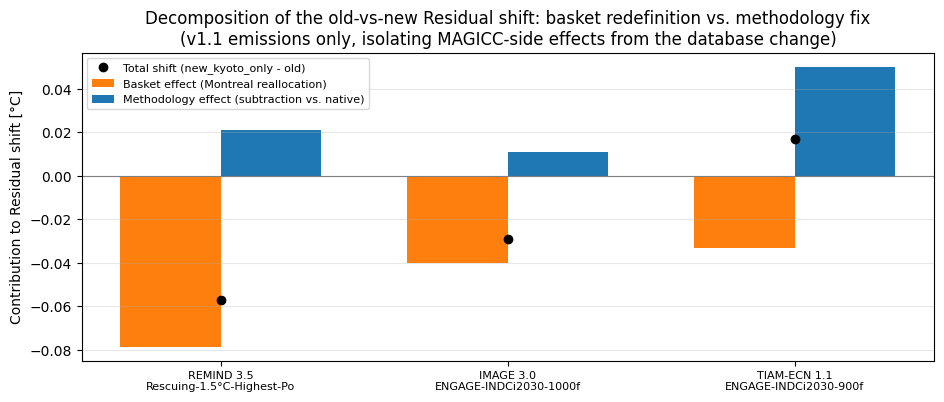

In [10]:
fig, ax = plt.subplots(figsize=(11, 4))

x = np.arange(len(SCENARIOS))
width = 0.35
labels = [f"{s['model']}\n{s['scenario'][:25]}" for s in SCENARIOS]

basket = decomposition_df["basket_effect (kyoto_only - kyoto_mhalo, same QEXTRA methodology)"].values
methodology = decomposition_df["methodology_effect (kyoto_mhalo QEXTRA - old native, same basket)"].values
total = decomposition_df["total_shift (new_kyoto_only - old)"].values

ax.bar(x - width/2, basket, width, label="Basket effect (Montreal reallocation)", color="tab:orange")
ax.bar(x + width/2, methodology, width, label="Methodology effect (subtraction vs. native)", color="tab:blue")
ax.plot(x, total, "ko", label="Total shift (new_kyoto_only - old)", zorder=3)

ax.axhline(0, color="gray", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("Contribution to Residual shift [\u00b0C]")
ax.set_title("Decomposition of the old-vs-new Residual shift: basket redefinition vs. methodology fix\n(v1.1 emissions only, isolating MAGICC-side effects from the database change)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis="y")

fig.savefig(PLOT_FOLDER / "306_ghg_methodology_decomposition.png", dpi=300, bbox_inches="tight")
plt.show()

## CO2_NZCO2 Check: Native vs. QEXTRA for the ZEC-Proxy Metric

`CO2_NZCO2` (the "held at net-zero CO2" ZEC-proxy) is *not* derived by subtraction from the real
scenario's own forcing at all - it comes from a completely separate emissions input: the `_NZCO2`-suffixed
stylised variant, where CO2 emissions are flat-lined at zero from the year net-zero CO2 is reached. In the
current pipeline, this variant's own `CO2` flag is still produced via the harvest+QEXTRA approach (an
`ANTHROPOGENIC`-mode harvest pass *of that stylised variant scenario*, then a QEXTRA pass driven by its own
harvested CO2 ERF) - not MAGICC's native `CO2` mode. This section tests directly whether that same
native-vs-QEXTRA choice matters for `CO2_NZCO2`, the way it clearly did for `NonCO2_GHG`/`Residual` above -
using the `_NZCO2` variant of the same 3 scenarios, v1.1 emissions only (`101_netzero_co2_extended.csv`).

In [11]:
NZCO2_FILE = OUTPUT_FOLDER / "101_netzero_co2_extended.csv"

NZCO2_SCENARIOS = [
    {**spec, "nzco2_scenario": spec["scenario"] + "_NZCO2"}
    for spec in SCENARIOS
]

nzco2_start = load_timeseries_csv(
    NZCO2_FILE,
    index_columns=["model", "scenario", "region", "variable", "unit"],
    out_columns_type=int,
    out_columns_name="year",
)
NZCO2_SCENARIOS

[{'model': 'REMIND 3.5',
  'scenario': 'Rescuing-1.5°C-Highest-Possible-Ambition',
  'year_netzero_co2': 2045,
  'nzco2_scenario': 'Rescuing-1.5°C-Highest-Possible-Ambition_NZCO2'},
 {'model': 'IMAGE 3.0',
  'scenario': 'ENGAGE-INDCi2030-1000f',
  'year_netzero_co2': 2069,
  'nzco2_scenario': 'ENGAGE-INDCi2030-1000f_NZCO2'},
 {'model': 'TIAM-ECN 1.1',
  'scenario': 'ENGAGE-INDCi2030-900f',
  'year_netzero_co2': 2069,
  'nzco2_scenario': 'ENGAGE-INDCi2030-900f_NZCO2'}]

In [12]:
nzco2_results = {}  # (model, nzco2_scenario, flag) -> wide GSAT DataFrame (run_id x year)

for spec in NZCO2_SCENARIOS:
    model, nzco2_scenario = spec["model"], spec["nzco2_scenario"]
    print(f"\n{'='*70}\n{model} | {nzco2_scenario}\n{'='*70}")

    sanitized_model = sanitize_label(model)
    sanitized_scenario = sanitize_label(nzco2_scenario)
    scenario_root = DIAG_FOLDER / f"{sanitized_model}_{sanitized_scenario}"
    scenario_root.mkdir(parents=True, exist_ok=True)

    scenario_to_run = nzco2_start.loc[pd.IndexSlice[model, nzco2_scenario, :, :, :], :]

    # Pass 1: harvest (ANTHROPOGENIC, of the _NZCO2 stylised variant itself) - only CO2 ERF needed here
    print("  Running harvest (ANTHROPOGENIC) pass...")
    erf_runner = build_scm_runner(
        output_variables=("Surface Air Temperature Change", *CO2_EFFRF_COMPONENTS)
    )
    erf_runner.climate_models_cfgs["MAGICC7"] = [
        {**c, "rf_total_runmodus": "ANTHROPOGENIC"}
        for c in erf_runner.climate_models_cfgs["MAGICC7"]
    ]
    erf_results = erf_runner(scenario_to_run)
    nzco2_results[(model, nzco2_scenario, "ANTHROPOGENIC")] = to_wide_gsat(
        erf_results.loc[pix.isin(variable=["Surface Air Temperature Change"])]
    )

    # Pass 2: QEXTRA CO2-only (current production methodology for CO2_NZCO2)
    print("  Running QEXTRA_CO2...")
    nzco2_results[(model, nzco2_scenario, "QEXTRA_CO2")] = run_qextra_pass(
        erf_results, CO2_EFFRF_COMPONENTS, "QEXTRA_CO2", scenario_root / "qextra_forcing"
    )

    # Pass 3: native CO2 (old-style methodology)
    print("  Running NATIVE_CO2...")
    nzco2_results[(model, nzco2_scenario, "NATIVE_CO2")] = run_native_pass(scenario_to_run, "CO2")

    for flag, df in nzco2_results.items():
        if flag[0] == model and flag[1] == nzco2_scenario:
            df.to_csv(scenario_root / f"{flag[2]}.csv")

print("\nAll CO2_NZCO2 passes complete.")
{k: v.shape for k, v in nzco2_results.items()}


REMIND 3.5 | Rescuing-1.5°C-Highest-Possible-Ambition_NZCO2
  Running harvest (ANTHROPOGENIC) pass...


Climate models:   0%|          | 0/1 [00:00<?, ?it/s]

Scenario batch:   0%|          | 0/1 [00:00<?, ?it/s]

Climate models:   0%|          | 0.00/1.00 [00:00<?, ?it/s]

[WARNING] 10:35:04 - openscm_runner.adapters.magicc7.magicc7: Historical data has not been checked


...

/Users/hoegner/GitHub/ar7_netzero_assessment/.venv/lib/python3.13/site-packages/jwt/api_jwt.py:147: InsecureKeyLengthWarning: The HMAC key is 20 bytes long, which is below the minimum recommended length of 32 bytes for SHA256. See RFC 7518 Section 3.2.
  return self._jws.encode(
/Users/hoegner/GitHub/ar7_netzero_assessment/.venv/lib/python3.13/site-packages/jwt/api_jwt.py:147: InsecureKeyLengthWarning: The HMAC key is 20 bytes long, which is below the minimum recommended length of 32 bytes for SHA256. See RFC 7518 Section 3.2.
  return self._jws.encode(


Parallel runs:   0%|          | 0.00/21.0 [00:00<?, ?it/s]

/Users/hoegner/GitHub/ar7_netzero_assessment/.venv/lib/python3.13/site-packages/jwt/api_jwt.py:147: InsecureKeyLengthWarning: The HMAC key is 20 bytes long, which is below the minimum recommended length of 32 bytes for SHA256. See RFC 7518 Section 3.2.
  return self._jws.encode(
/Users/hoegner/GitHub/ar7_netzero_assessment/.venv/lib/python3.13/site-packages/jwt/api_jwt.py:147: InsecureKeyLengthWarning: The HMAC key is 20 bytes long, which is below the minimum recommended length of 32 bytes for SHA256. See RFC 7518 Section 3.2.
  return self._jws.encode(



All CO2_NZCO2 passes complete.


{('REMIND 3.5',
  'Rescuing-1.5°C-Highest-Possible-Ambition_NZCO2',
  'ANTHROPOGENIC'): (25, 351),
 ('REMIND 3.5',
  'Rescuing-1.5°C-Highest-Possible-Ambition_NZCO2',
  'QEXTRA_CO2'): (25, 351),
 ('REMIND 3.5',
  'Rescuing-1.5°C-Highest-Possible-Ambition_NZCO2',
  'NATIVE_CO2'): (25, 351),
 ('IMAGE 3.0', 'ENGAGE-INDCi2030-1000f_NZCO2', 'ANTHROPOGENIC'): (25, 351),
 ('IMAGE 3.0', 'ENGAGE-INDCi2030-1000f_NZCO2', 'QEXTRA_CO2'): (25, 351),
 ('IMAGE 3.0', 'ENGAGE-INDCi2030-1000f_NZCO2', 'NATIVE_CO2'): (25, 351),
 ('TIAM-ECN 1.1', 'ENGAGE-INDCi2030-900f_NZCO2', 'ANTHROPOGENIC'): (25, 351),
 ('TIAM-ECN 1.1', 'ENGAGE-INDCi2030-900f_NZCO2', 'QEXTRA_CO2'): (25, 351),
 ('TIAM-ECN 1.1', 'ENGAGE-INDCi2030-900f_NZCO2', 'NATIVE_CO2'): (25, 351)}

In [13]:
co2_nzco2_records = []
for spec in NZCO2_SCENARIOS:
    model, nzco2_scenario, year_nz = spec["model"], spec["nzco2_scenario"], spec["year_netzero_co2"]

    qextra_delta = extract_delta_netzero_co2(nzco2_results[(model, nzco2_scenario, "QEXTRA_CO2")], year_nz)
    native_delta = extract_delta_netzero_co2(nzco2_results[(model, nzco2_scenario, "NATIVE_CO2")], year_nz)

    co2_nzco2_records.append({
        "model": model,
        "scenario": spec["scenario"],
        "CO2_NZCO2_QEXTRA (current methodology)": qextra_delta.median(),
        "CO2_NZCO2_NATIVE (old-style methodology)": native_delta.median(),
        "methodology_effect (QEXTRA - NATIVE)": qextra_delta.median() - native_delta.median(),
        "n_members": qextra_delta.notna().sum(),
    })

co2_nzco2_df = pd.DataFrame(co2_nzco2_records)
co2_nzco2_df.to_csv(DIAG_FOLDER / "306_co2_nzco2_methodology_comparison.csv", index=False)

print("Median delta_netzero_co2 [\u00b0C] for CO2_NZCO2, native vs. QEXTRA:")
co2_nzco2_df.round(4)

Median delta_netzero_co2 [°C] for CO2_NZCO2, native vs. QEXTRA:


,model,scenario,CO2_NZCO2_QEXTRA (current methodology),CO2_NZCO2_NATIVE (old-style methodology),methodology_effect (QEXTRA - NATIVE),n_members
0,REMIND 3.5,Rescuing-1.5°C-Highest-Possible-Ambition,-0.0511,-0.0888,0.0377,25
1,IMAGE 3.0,ENGAGE-INDCi2030-1000f,-0.0353,-0.0550,0.0198,25
2,TIAM-ECN 1.1,ENGAGE-INDCi2030-900f,-0.0395,-0.0342,-0.0053,25


## CO2 and CH4 Emissions Timeseries for the 3 Selected Scenarios

Total CO2 = `Emissions|CO2|Fossil` + `Emissions|CO2|Biosphere` (this dataset reports CO2 split by
source rather than as a single aggregate); CH4 is reported directly as `Emissions|CH4`.

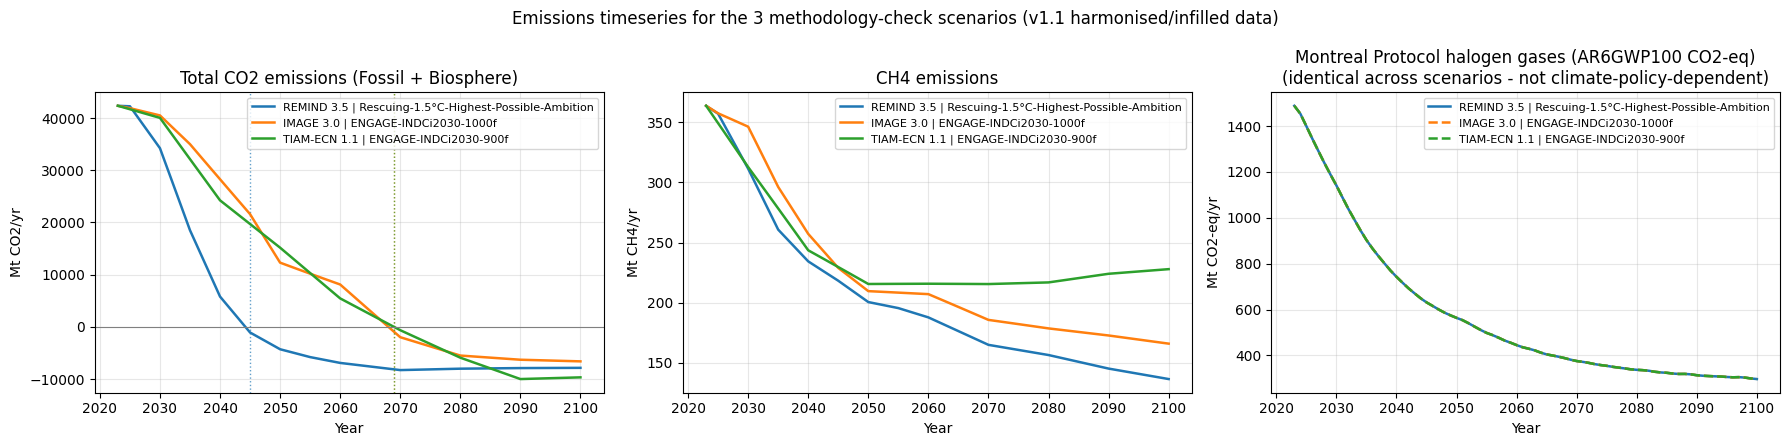

In [4]:
import pyam
from utils import convert_units_to_co2_equiv

colors = {
    "REMIND 3.5": "tab:blue",
    "IMAGE 3.0": "tab:orange",
    "TIAM-ECN 1.1": "tab:green",
}

# Montreal Protocol halogen gases (MAGICC's "MHALOSUM" aggregate): CFCs, HCFCs, Halons,
# CCl4, CH3Br, CH3Cl - per pymagicc's own documented composition of that aggregate.
MHALO_SPECIES = [
    "Emissions|CFC11", "Emissions|CFC12", "Emissions|CFC113", "Emissions|CFC114", "Emissions|CFC115",
    "Emissions|HCFC22", "Emissions|HCFC141b", "Emissions|HCFC142b",
    "Emissions|Halon1211", "Emissions|Halon1301", "Emissions|Halon2402", "Emissions|Halon1202",
    "Emissions|CCl4", "Emissions|CH3Br", "Emissions|CH3Cl",
]

fig, (ax_co2, ax_ch4, ax_mhalo) = plt.subplots(1, 3, figsize=(18, 4.5))

for spec in SCENARIOS:
    model, scenario = spec["model"], spec["scenario"]
    label = f"{model} | {scenario}"
    color = colors[model]

    scen_data = start.loc[pd.IndexSlice[model, scenario, :, :, :], :]

    co2_total = (
        scen_data
        .loc[pix.isin(variable=["Emissions|CO2|Fossil", "Emissions|CO2|Biosphere"])]
        .groupby(level=["model", "scenario"])
        .sum(numeric_only=True)
    )
    year_cols_co2 = [c for c in co2_total.columns if isinstance(c, int)]
    ax_co2.plot(year_cols_co2, co2_total[year_cols_co2].iloc[0], label=label, color=color, linewidth=1.8)

    ch4_total = scen_data.loc[pix.isin(variable=["Emissions|CH4"])]
    year_cols_ch4 = [c for c in ch4_total.columns if isinstance(c, int)]
    ax_ch4.plot(year_cols_ch4, ch4_total[year_cols_ch4].iloc[0], label=label, color=color, linewidth=1.8)

    # Mark each scenario's own net-zero CO2 year
    ax_co2.axvline(spec["year_netzero_co2"], color=color, linestyle=":", linewidth=1, alpha=0.7)

    # Montreal halogens: sum native-unit species via AR6GWP100 CO2-equivalent conversion
    mhalo_native = scen_data.loc[pix.isin(variable=MHALO_SPECIES)].reset_index()
    mhalo_iamdf = pyam.IamDataFrame(mhalo_native)
    mhalo_co2eq = convert_units_to_co2_equiv(mhalo_iamdf, "AR6GWP100")
    mhalo_by_year = mhalo_co2eq.data.groupby("year")["value"].sum().sort_index()
    ax_mhalo.plot(
        mhalo_by_year.index, mhalo_by_year.values, label=label, color=color, linewidth=1.8,
        linestyle="--" if model != "REMIND 3.5" else "-",
    )

ax_co2.axhline(0, color="gray", linewidth=0.8)
ax_co2.set_title("Total CO2 emissions (Fossil + Biosphere)")
ax_co2.set_xlabel("Year")
ax_co2.set_ylabel("Mt CO2/yr")
ax_co2.grid(alpha=0.3)
ax_co2.legend(fontsize=8)

ax_ch4.set_title("CH4 emissions")
ax_ch4.set_xlabel("Year")
ax_ch4.set_ylabel("Mt CH4/yr")
ax_ch4.grid(alpha=0.3)
ax_ch4.legend(fontsize=8)

ax_mhalo.set_title("Montreal Protocol halogen gases (AR6GWP100 CO2-eq)\n(identical across scenarios - not climate-policy-dependent)")
ax_mhalo.set_xlabel("Year")
ax_mhalo.set_ylabel("Mt CO2-eq/yr")
ax_mhalo.grid(alpha=0.3)
ax_mhalo.legend(fontsize=8)

fig.suptitle("Emissions timeseries for the 3 methodology-check scenarios (v1.1 harmonised/infilled data)")
fig.tight_layout()
fig.savefig(PLOT_FOLDER / "306_co2_ch4_emissions_timeseries.png", dpi=300, bbox_inches="tight")
plt.show()